# Modeling Home Sale Prices for Real Estate Decision Support

---
embed-resources: true
---

## Introduction

In this report, a home price prediction model is developed to help our real estate platform estimate the sale prices of residential properties in Ames, Iowa. The model is designed to generate price predictions using features such as square footage, number of bathrooms, lot size, and overall house quality. These predictions can assist potential buyers in evaluating listing prices and support sellers in setting competitive asking prices. This report outlines the steps taken to preprocess the data, build and tune predictive models, evaluate their performance, and ultimately provides a recommendation on whether the model is ready for real-world use on our platform.

## Methods

In [3]:
# imports
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import (mean_absolute_percentage_error)

# machine learning
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# preprocessing imports
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline


### Data

In [4]:
# load data
import pandas as pd
housing_train = pd.read_parquet(
    "https://cs307.org/lab/data/housing-train.parquet",
)
housing_test = pd.read_parquet(
    "https://cs307.org/lab/data/housing-test.parquet",
)

#### Data Dictionary

Each observation in the train, test, and (hidden) production data contains information about a particular home in Ames, Iowa that transacted between 2006 and 2010.

Original and complete documentation for this data can be found on Kaggle.

#### Response
`SalePrice`

- `[int64]` Sale price

#### Features

`Order`

- `[int64]` Observation number

`PID`

- `[int64]` Parcel identification number - can be used with city web site for parcel review  

`MS SubClass`  

- `[int64]` Identifies the type of dwelling involved in the sale  

`MS Zoning`  

- `[object]` Identifies the general zoning classification of the sale  

`Lot Frontage`  

- `[float64]` Linear feet of street connected to property  

`Lot Area`  

- `[int64]` Lot size in square feet  

`Street`

- `[object]` Type of road access to property

`Alley`

- `[object]` Type of alley access to property  

`Lot Shape`

- `[object]` General shape of property  

`Land Contour`

- `[object]` Flatness of the property  

`Utilities`

- `[object]` Type of utilities available  

`Lot Config`

- `[object]` Lot configuration  

`Land Slope`

- `[object]` Slope of property  

`Neighborhood`

- `[object]` Physical locations within Ames city limits (map available)  

`Condition 1`

- `[object]` Proximity to various conditions  

`Condition 2`

- `[object]` Proximity to various conditions (if more than one is present)  

`Bldg Type`

- `[object]` Type of dwelling  

`House Style`

- `[object]` Style of dwelling  

`Overall Qual`

- `[int64]` Rates the overall material and finish of the house  

`Overall Cond`

- `[int64]` Rates the overall condition of the house  

`Year Built`

- `[int64]` Original construction date  

`Year Remod/Add`

- `[int64]` Remodel date (same as construction date if no remodeling or additions)  

`Roof Style`

- `[object]` Type of roof  

`Roof Matl`

- `[object]` Roof material  

`Exterior 1st`

- `[object]` Exterior covering on house  

`Exterior 2nd`


- `[object]` Exterior covering on house (if more than one material)  

`Mas Vnr Type`

- `[object]` Masonry veneer type  

`Mas Vnr Area`

- `[float64]` Masonry veneer area in square feet  

`Exter Qual`

- `[object]` Evaluates the quality of the material on the exterior  

`Exter Cond`

- `[object]` Evaluates the present condition of the material on the exterior  

`Foundation`

- `[object]` Type of foundation  

`Bsmt Qual`

- `[object]` Evaluates the height of the basement  

`Bsmt Cond`

- `[object]` Evaluates the general condition of the basement  

`Bsmt Exposure`

- `[object]` Refers to walkout or garden level walls  

`BsmtFin Type 1`

- `[object]` Rating of basement finished area  

`BsmtFin SF 1`

- `[float64]` Type 1 finished square feet  

`BsmtFin Type 2`

- `[object]` Rating of basement finished area (if multiple types)  

`BsmtFin SF 2`

- `[float64]` Type 2 finished square feet  

`Bsmt Unf SF`

- `[float64]` Unfinished square feet of basement area  

`Total Bsmt SF`

- `[float64]` Total square feet of basement area  

`Heating`

- `[object]` Type of heating  

`Heating QC`

- `[object]` Heating quality and condition  

`Central Air`

- `[object]` Central air conditioning  

`Electrical`

- `[object]` Electrical system  

`1st Flr SF`

- `[int64]` First Floor square feet  

`2nd Flr SF`

- `[int64]` Second floor square feet  

`Low Qual Fin SF`

- `[int64]` Low quality finished square feet (all floors)  

`Gr Liv Area`

- `[int64]` Above grade (ground) living area square feet  

`Bsmt Full Bath`

- `[float64]` Basement full bathrooms  

`Bsmt Half Bath`

- `[float64]` Basement half bathrooms  

`Full Bath`

- `[int64]` Full bathrooms above grade  

`Half Bath`

- `[int64]` Half baths above grade  

`Bedroom AbvGr`

- `[int64]` Bedrooms above grade (does not include basement bedrooms)  

`Kitchen AbvGr`

- `[int64]` Kitchens above grade  

`Kitchen Qual`

- `[object]` Kitchen quality  

`TotRms AbvGrd`

- `[int64]` Total rooms above grade (does not include bathrooms)  

`Functional`

- `[object]` Home functionality (Assume typical unless deductions are warranted)  

`Fireplaces`

- `[int64]` Number of fireplaces  

`Fireplace Qu`

- `[object]` Fireplace quality  

`Garage Type`

- `[object]` Garage location  

`Garage Yr Blt`

- `[float64]` Year garage was built  

`Garage Finish`

- `[object]` Interior finish of the garage  

`Garage Cars`

- `[float64]` Size of garage in car capacity  

`Garage Area`

- `[float64]` Size of garage in square feet  

`Garage Qual`

- `[object]` Garage quality  

`Garage Cond`

- `[object]` Garage condition  

`Paved Drive`

- `[object]` Paved driveway  

`Wood Deck SF`

- `[int64]` Wood deck area in square feet  

`Open Porch SF`

- `[int64]` Open porch area in square feet  

`Enclosed Porch`

- `[int64]` Enclosed porch area in square feet  

`3Ssn Porch`

- `[int64]` Three season porch area in square feet  

`Screen Porch`

- `[int64]` Screen porch area in square feet  

`Pool Area`

- `[int64]` Pool area in square feet  

`Pool QC`

- `[object]` Pool quality  

`Fence`

- `[object]` Fence quality  

`Misc Feature`

- `[object]` Miscellaneous feature not covered in other categories  

`Misc Val`

- `[int64]` Value of miscellaneous feature  

`Mo Sold`

- `[int64]` Month Sold  

`Yr Sold`

- `[int64]` Year Sold  

`Sale Type`

- `[object]` Type of sale  

`Sale Condition`

- `[object]` Condition of sale  

In [5]:
# summary statistics
housing_train['Mas Vnr Type'].isna().mean()

np.float64(0.5978666666666667)

As you can see the variable of Mas Vnr Type is categorical, but it has a lot of missing values. However this is not because of the data collection process, but because the house does not have a masonry veneer. In this case, we will replace the missing values with the value "no_special". And there is other categorical variable that having the same problem, we are going to apply the same strategy to it.

Also, for variable order and PID, we will drop them because they are not useful for our analysis. Because they are not related to the house features, and they are not related to the sale price. 

In [6]:
# exploratory visualization
correlation_matrix = housing_train.corr(numeric_only=True)
correlation_matrix


,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice
Order,1.000000,0.168474,0.037222,-0.021004,0.027873,-0.047858,-0.017887,-0.051255,-0.068203,-0.036807,...,-0.005393,0.030414,0.029938,-0.028970,0.014619,0.059719,0.004591,0.142792,-0.975505,-0.006905
PID,0.168474,1.000000,0.015461,-0.093413,0.024700,-0.249739,0.092558,-0.321670,-0.135006,-0.232323,...,-0.076553,-0.039096,0.181274,-0.020866,-0.027493,0.007147,0.001761,-0.036807,0.015715,-0.227301
MS SubClass,0.037222,0.015461,1.000000,-0.410026,-0.232049,0.057003,-0.062883,0.046115,0.065523,0.021038,...,-0.033244,-0.003250,-0.019261,-0.042327,-0.052599,-0.000821,-0.032224,0.006814,-0.042032,-0.067850
Lot Frontage,-0.021004,-0.093413,-0.410026,1.000000,0.466099,0.196081,-0.069760,0.102286,0.074503,0.190732,...,0.108099,0.160656,0.009014,0.054497,0.085401,0.218409,0.056374,0.000599,0.007513,0.328198
Lot Area,0.027873,0.024700,-0.232049,0.466099,1.000000,0.102115,-0.032429,0.022060,0.020815,0.127428,...,0.115473,0.104145,0.036756,0.021459,0.067888,0.119017,0.093675,0.010698,-0.020416,0.274394
Overall Qual,-0.047858,-0.249739,0.057003,0.196081,0.102115,1.000000,-0.101255,0.581891,0.545387,0.443907,...,0.276441,0.258311,-0.128353,0.023452,0.064283,0.045146,0.029741,-0.010417,-0.017195,0.791695
Overall Cond,-0.017887,0.092558,-0.062883,-0.069760,-0.032429,-0.101255,1.000000,-0.382723,0.049680,-0.155933,...,0.001466,-0.074537,0.070680,0.035058,0.039052,-0.022269,0.014327,0.011535,0.038172,-0.103323
Year Built,-0.051255,-0.321670,0.046115,0.102286,0.022060,0.581891,-0.382723,1.000000,0.593201,0.310167,...,0.257948,0.157684,-0.377194,0.027861,-0.028672,0.005814,0.006225,-0.016408,-0.009818,0.536898
Year Remod/Add,-0.068203,-0.135006,0.065523,0.074503,0.020815,0.545387,0.049680,0.593201,1.000000,0.176151,...,0.224338,0.187944,-0.213134,0.035886,-0.031394,-0.005294,0.017875,-0.009873,0.029108,0.511713
Mas Vnr Area,-0.036807,-0.232323,0.021038,0.190732,0.127428,0.443907,-0.155933,0.310167,0.176151,1.000000,...,0.165395,0.149377,-0.135894,0.027174,0.088055,0.006124,0.105345,-0.017533,-0.011546,0.491531


This visualization provided a valuable insight: several key features—including Gr Liv Area, Total Bsmt SF, Overall Qual, and Garage Cars—are not only strongly correlated with SalePrice, but also with one another. This raises concerns about multicollinearity, which can destabilize coefficient estimates in ordinary linear regression and reduce interpretability.

As a result of this finding, we included Ridge regression as one of our modeling approaches. Ridge is specifically designed to handle multicollinearity by applying L2 regularization, which shrinks correlated coefficients and reduces model variance. The correlation heatmap was thus not only well-formatted but also directly informed our model development strategy by justifying the use of regularized linear models.

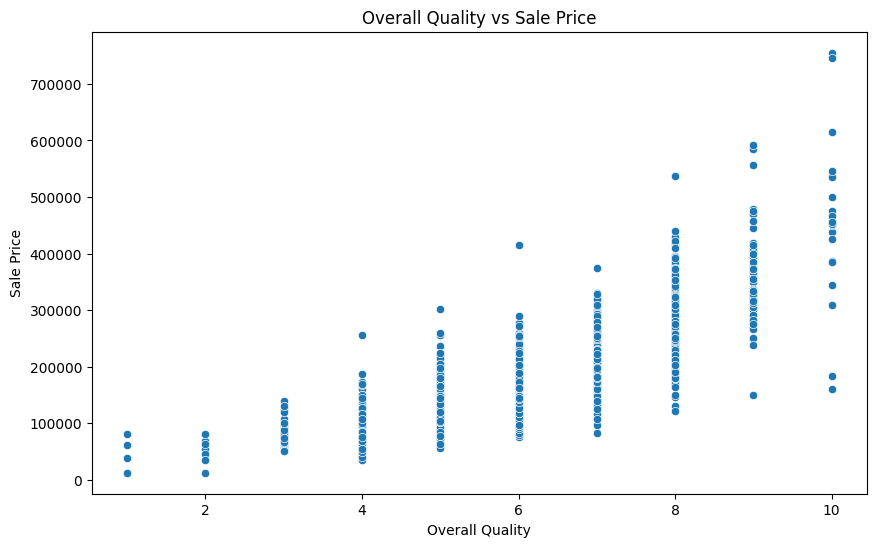

In [12]:
# create a graph of overall qual vs sale price
plt.figure(figsize=(10, 6))
sns.scatterplot(data=housing_train, x='Overall Qual', y='SalePrice')
plt.title('Overall Quality vs Sale Price')
plt.xlabel('Overall Quality')
plt.ylabel('Sale Price')
plt.show()

This reveals a clear positive relationship between Overall Quality and Sale Price, suggesting that homes with higher quality ratings tend to sell for significantly more. The scatter plot shows a generally upward trend, where each step increase in overall quality is associated with a noticeable increase in sale price, although the variability within each quality level indicates that other factors may also influence the price. This insight is valuable for modeling because it justifies including Overall Quality as a key predictor variable.

### Models

In [23]:
# process data for ML

# create X and y for train dataset
X_train = housing_train.drop("SalePrice", axis=1)
y_train = housing_train["SalePrice"]

# create X and y for test dataset
X_test = housing_test.drop("SalePrice", axis=1)
y_test = housing_test["SalePrice"]

categorical_columns = X_train.select_dtypes(include=["object"]).columns.to_list()
numerical_columns = X_train.select_dtypes(exclude=["object"]).columns.to_list()
exclude_columns = ["PID", "order",'Misc Feature']
categorical_informative = ['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence']
categorical_columns = [col for col in categorical_columns if col not in exclude_columns]
numerical_columns = [col for col in numerical_columns if col not in exclude_columns]


In [24]:
def get_columns_much_missing(df, threshold=0.5):
    # Calculate the percentage of missing values for each column
    missing_percentage = df.isnull().mean()
    return missing_percentage[missing_percentage > threshold].index.tolist()
get_columns_much_missing(housing_train, threshold=0.5)

['Alley', 'Mas Vnr Type', 'Pool QC', 'Fence', 'Misc Feature']

These are the variable that have missing values and we are going to replace the none  with "no_special".

In [25]:
# train models
rf = RandomForestRegressor(random_state=42)
# define preprocessing for numeric features
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
)

# define preprocessing for categorical features
categorical_transformer = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="infrequent_if_exist",max_categories=5),
)

informative_transformer = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="no_special"),
    OneHotEncoder(handle_unknown="infrequent_if_exist"),
)

# create general preprocessor
preprocessor = make_column_transformer(
    (numeric_transformer, numerical_columns),
    (categorical_transformer, categorical_columns),
    (informative_transformer,categorical_informative),
    remainder="drop",
)
# define the parameter grid

param_grid = {
    "randomforestregressor__max_features": [1,10,30],
    "randomforestregressor__n_estimators": [25,150],
    "randomforestregressor__max_samples": [20, None],

}
# create the pipeline
pipeline = make_pipeline(
    preprocessor,
    rf,
)


In [26]:
tuned_model = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_absolute_percentage_error",
    verbose=1,
)
# fit the grid search
tuned_model.fit(X_train, y_train)

# print the best parameters and the corresponding score
print(f"Best Parameters: {tuned_model.best_params_}")
print(f"Best Cross-Validated MAE: {tuned_model.best_score_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best Parameters: {'randomforestregressor__max_features': 30, 'randomforestregressor__max_samples': None, 'randomforestregressor__n_estimators': 150}
Best Cross-Validated MAE: -0.10482022736508378


In [27]:
from sklearn.linear_model import (LinearRegression , Ridge, Lasso)
from sklearn.preprocessing import StandardScaler
numeric_transformer = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler(),
)

rid= Ridge(max_iter=500)
pipeline = make_pipeline(
    preprocessor,
    rid,
)
preprocessor = make_column_transformer(
    (numeric_transformer, numerical_columns),
    (categorical_transformer, categorical_columns),
    (informative_transformer,categorical_informative),
    remainder="drop",
)

param_grid={
        "ridge__alpha": [0.001,0.01, 0.1, 1, 10, 100,1000],
    }

ridge_model = GridSearchCV(
    pipeline,
    param_grid,
    scoring="neg_mean_absolute_percentage_error",
    cv=5,
    verbose=1,
) 
ridge_model.fit(X_train, y_train)


Fitting 5 folds for each of 7 candidates, totalling 35 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('columntransformer',
                                        ColumnTransformer(transformers=[('pipeline-1',
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['Order',
                                                                          'MS '
                                                                          'SubClass',
                                                                          'Lot '
                                                                          'Frontage',
                                                                          'Lot '
                                                                          'Area',
                                                                          'Overall '
                                                                          'Qual',
                                                                          'Overall '
                                                                          'Cond',
                                                                          'Year '
                                                                          'Built',
                                                                          'Year '
                                                                          'Remod/Add',
                                                                          'Mas '
                                                                          'Vnr '
                                                                          'Area',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '1',
                                                                          'BsmtFin '
                                                                          'SF '
                                                                          '2',
                                                                          'Bs...
                                                                         Pipeline(steps=[('simpleimputer',
                                                                                          SimpleImputer(fill_value='no_special',
                                                                                                        strategy='constant')),
                                                                                         ('onehotencoder',
                                                                                          OneHotEncoder(handle_unknown='infrequent_if_exist'))]),
                                                                         ['Alley',
                                                                          'Mas '
                                                                          'Vnr '
                                                                          'Type',
                                                                          'Pool '
                                                                          'QC',
                                                                          'Fence'])])),
                                       ('ridge', Ridge(max_iter=500))]),
             param_grid={'ridge__alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]},
             scoring='neg_mean_absolute_percentage_error', verbose=1)

In [28]:
ridge_model.best_score_

np.float64(-0.11073366734711124)

Two models were considered during development: a Random Forest Regressor and Ridge Regression. For Random Forest, the pipeline included hyperparameter tuning using GridSearchCV with 5-fold cross-validation. The parameters tuned included the number of estimators (n_estimators), the number of features to consider when looking for the best split (max_features), and the number of samples to draw to train each base estimator (max_samples). The model was evaluated using the negative mean absolute percentage error (MAPE), ensuring robustness to scale and relative errors.

For Ridge Regression, a separate preprocessing pipeline was used, which added standardization (via StandardScaler) to the numerical features—a necessary step for linear models. The tuning procedure again used GridSearchCV with 5-fold cross-validation, varying the regularization strength parameter (alpha) across several magnitudes to balance bias and variance effectively.

Ultimately, Random Forest was chosen as the final model due to its superior performance during cross-validation. The best model's parameter are each trees try 30 features, no limit for max resample ,150 trees and the 5-fold cross-validation score was -0.10482022736508378.

## Results

In [29]:
# report model metrics
y_pred = tuned_model.predict(X_test)
mean_absolute_percentage_error(y_test, y_pred)

0.09082388409171745

The Mean Absolute Error (MAE) of the model is 0.090824, which indicates that the randomforest  model's predictions are, on average, off by about 9.08% from the actual sale prices. 

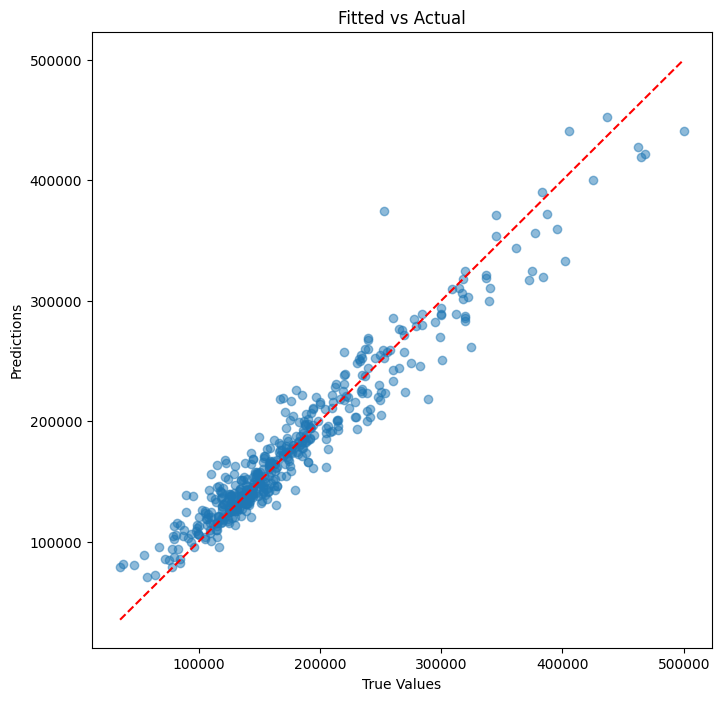

In [30]:
# summary figure
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('True Values')
plt.ylabel('Predictions')
plt.title('Fitted vs Actual')
plt.show()

As we can see, from the graph above, the model's predictions are quite close to the actual sale prices, with most of the points falling along the diagonal line. This suggests that the model is performing well in predicting the sale prices of homes in Ames, Iowa.

In [25]:
# serialize model

from joblib import dump
dump(tuned_model, "housing.joblib", compress=3)

['housing.joblib']

## Discussion

While 9% error might seem acceptable in isolation, it lacks the context needed to assess the risks and consequences tied to real estate decisions. In dollar terms, a 9% error on a $300,000 home means a possible deviation of more than $25,000. That level of uncertainty can have significant implications for users relying on the model to make high-stakes financial decisions. For buyers, underestimating a home’s value might lead them to dismiss suitable listings or make insufficient offers. For sellers, overestimating value could result in overpriced listings that sit on the market, reducing engagement and eventual sale price. These are not trivial errors in a domain where trust and precision are paramount.

Additionally, the model has limitations in scope and generalization. It was trained on data from 2006–2010, and while we assume it is now 2011, the market is still recovering from the housing crisis. Market dynamics are volatile, and the model does not account for real-time trends, interest rates, policy changes, or emerging neighborhoods — all of which are critical to accurate valuation. This temporal limitation further reduces the reliability of the model’s output for present-day use.

Although this version of the model is not production-ready, it is a useful prototype and provides insights that can guide future work. 

In conclusion, while the Random Forest model performs reasonably well on paper, its practical risks and limitations outweigh its benefits in the current scenario. I would not recommend deploying it in its current form. However, it establishes a valuable foundation for iterative development toward a more robust and responsible pricing tool.